-0.019392547244381438


,0,1,2,3,4,5,6,7,8,9,...,71,72,73,74,75,76,77,78,79,80
0,2.111+0.000j,1.000-0.019j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,...,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,1.000+0.019j
1,1.000+0.019j,-1.995+0.000j,1.000-0.019j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,...,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j
2,0.000+0.000j,1.000+0.019j,2.465+0.000j,1.000-0.019j,0.000+0.000j,0.000+0.000j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,...,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j
3,0.000+0.000j,0.000+0.000j,1.000+0.019j,3.540+0.000j,1.000-0.019j,0.000+0.000j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,...,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j
4,0.000+0.000j,0.000+0.000j,0.000+0.000j,1.000+0.019j,3.592+0.000j,1.000-0.019j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,...,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,...,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,1.000+0.019j,1.367+0.000j,1.000-0.019j,0.000+0.000j,0.000+0.000j,0.000+0.000j
77,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,...,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.000+0.000j,1.000+0.019j,-1.852+0.000j,1.000-0.019j,0.000+0.000j,0.000+0.000j
78,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,...,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.000+0.000j,0.000+0.000j,1.000+0.019j,-1.158+0.000j,1.000-0.019j,0.000+0.000j
79,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,...,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.000+0.000j,0.000+0.000j,0.000+0.000j,1.000+0.019j,-3.728+0.000j,1.000-0.019j


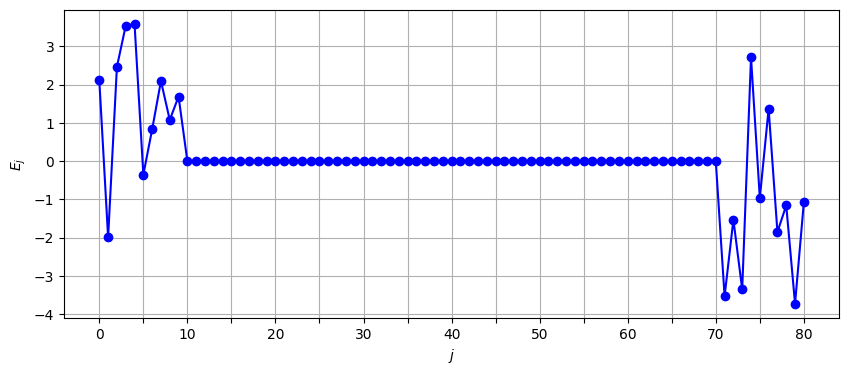

Evolution saved to qw_history.npz


In [ ]:
import numpy as np # for doing stuff with numbers
from scipy.linalg import expm # this we need for the time evolution operator
import matplotlib.pyplot as plt # added for plotting the on-site energies
import pandas as pd # added for formatted matrix output

np.random.seed(13) # fixed the random seed here!

##########################################
# 1. define parameters for a qw on a line
##########################################
num_sites = 81
t_max = 2000 # duration of the evolution (renamed to avoid overwriting)
num_steps = 100 # number of frames for our history
times = np.linspace(0, t_max, num_steps) # array of times
#phi = 0 # no chirality
phi = -np.pi/float(2*num_sites) # maximal influence (phase along the loop is pi/2)
print(phi)

##########################################
# 2. Laplacian matrix for a 1D line (L = D - A)
##########################################
# on-site energies seto to 0
diag = 0 * np.eye(num_sites)

# random noise at the boundaries
boundary_width = 10 # number of sites at the left and right boundaries
noise_strength = 1.8 # amplitude of the random noise

for i in list(range(0, boundary_width)) + list(range(num_sites - boundary_width, num_sites)):
    # uniform random distribution between -noise_strength and +noise_strength
    diag[i, i] = np.random.uniform(-noise_strength, noise_strength)

# first neighbor hopping
upper_diag = np.exp(1j * phi) * np.eye(num_sites, k=1)
lower_diag = np.exp(-1j * phi) * np.eye(num_sites, k=-1)
# sum
L = diag + upper_diag + lower_diag
# add periodic boundary conditions (it becomes a ring...)
L[0,-1] = np.exp(-1j * phi)
L[-1,0] = np.exp(1j * phi)
# check the form of the matrix
import pandas as pd
df = pd.DataFrame(L)
pd.set_option("display.precision", 3)
display(df)

# plot the on-site energies to check what's going on
plt.figure(figsize=(10, 4))
plt.plot(np.diag(diag).real, marker='o', linestyle='-', color='b')
plt.xlabel("$j$")
plt.ylabel("$E_j$")
ticks = np.arange(0, len(np.diag(diag)), 5)
labels = [str(t) if t % 10 == 0 else '' for t in ticks]
plt.xticks(ticks, labels)
plt.grid(True)
plt.show()

##########################################
# 3. initialization of the state
##########################################

#psi_0 = np.zeros(num_sites, dtype=complex)
#psi_0[int(num_sites/2)] = 1.0 # start at the very center
#psi_0[0] = 1.0 # start at the very left


##########################################
# 3. initialization of the state
##########################################

x_0 = int(num_sites/2) # start at the very center
sigma = 4.0 # spatial width of the wavepacket
k_0 = np.pi / 2 # initial momentum kick

# create an array of all site indices
j = np.arange(num_sites)

# build the Gaussian wavepacket with a phase gradient
psi_0 = np.exp(-(j - x_0)**2 / (4 * sigma**2)) * np.exp(1j * k_0 * j)

# normalize the state so that the sum of probabilities equals 1
psi_0 = psi_0 / np.linalg.norm(psi_0)

##########################################
# 4. time evolution (time-indep. H)
##########################################
gamma = 1.0 # hopping rate
H = gamma * L

# empty matrix to store the history: rows = time steps, cols = sites
history_psi = np.zeros((num_steps, num_sites), dtype=complex)

for i, current_t in enumerate(times):
    U = expm(-1j * H * current_t) # exp(-iHt/hbar), hbar set to 1
    psi_t = np.dot(U,psi_0) # matrix multiplication
    history_psi[i, :] = psi_t

##########################################
# 5. probabilities calculation
##########################################
probabilities_history = np.abs(history_psi) ** 2
# no need to project it: this is done INTERNALLY

##########################################
# 6. save data to file
##########################################
# saving probabilities, times, and num_sites into a compressed .npz file
np.savez('qw_history.npz', probs=probabilities_history, times=times, num_sites=num_sites, boundary_width=boundary_width)
print("Evolution saved to qw_history.npz")